In [27]:
import numpy as np

from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import LSTM, Dense, Dropout

from tensorflow.keras.utils import to_categorical

In [28]:
import numpy as np

from tensorflow.keras.utils import to_categorical

In [29]:
X = np.load(
    r"D:\project\MindSense\Early_Detection\data\sequences\X.npy"
)

y = np.load(
    r"D:\project\MindSense\Early_Detection\data\sequences\y.npy"
)

In [30]:
print(X.shape)
print(y.shape)

(37160, 60, 11)
(37160,)


In [31]:
y = to_categorical(y)

In [32]:
print(y.shape)

(37160, 6)


In [33]:
print(X.shape)
print(y.shape)

(37160, 60, 11)
(37160, 6)


In [34]:
print(y.shape)

(37160, 6)


In [35]:
from sklearn.model_selection import train_test_split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [37]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    shuffle=False
)

In [38]:
print("Training:")
print(X_train.shape)
print(y_train.shape)

print("\nValidation:")
print(X_val.shape)
print(y_val.shape)

print("\nTesting:")
print(X_test.shape)
print(y_test.shape)

Training:
(23782, 60, 11)
(23782, 6)

Validation:
(5946, 60, 11)
(5946, 6)

Testing:
(7432, 60, 11)
(7432, 6)


In [39]:
print("Training:")
print(X_train.shape)
print(y_train.shape)

print("\nValidation:")
print(X_val.shape)
print(y_val.shape)

print("\nTesting:")
print(X_test.shape)
print(y_test.shape)

Training:
(23782, 60, 11)
(23782, 6)

Validation:
(5946, 60, 11)
(5946, 6)

Testing:
(7432, 60, 11)
(7432, 6)


In [40]:
print(X_train.shape)
print(y_train.shape)

print(X_val.shape)
print(y_val.shape)

print(X_test.shape)
print(y_test.shape)

(23782, 60, 11)
(23782, 6)
(5946, 60, 11)
(5946, 6)
(7432, 60, 11)
(7432, 6)


In [41]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [42]:
print(tf.__version__)

2.21.0


In [43]:
model = Sequential()

model.add(
    LSTM(
        units=64,
        input_shape=(60,11),
        return_sequences=False
    )
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        32,
        activation="relu"
    )
)

model.add(
    Dropout(0.2)
)

model.add(
    Dense(
        6,
        activation="softmax"
    )
)

d:\project\MindSense\Early_Detection\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [44]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [45]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,734 (84.90 KB)

 Trainable params: 21,734 (84.90 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
from tensorflow.keras.callbacks import EarlyStopping

In [47]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [48]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

In [49]:
y_train_labels = np.argmax(y_train, axis=1)

In [50]:
classes = np.unique(y_train_labels)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_labels
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(0.46490079171146514), np.int64(1): np.float64(1.3103030303030303), np.int64(2): np.float64(10.407877461706784), np.int64(3): np.float64(1.2796341135324185), np.int64(5): np.float64(0.8276318078997738)}


In [51]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_val, y_val),
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.2833 - loss: 1.3305 - val_accuracy: 0.3545 - val_loss: 1.2427
Epoch 2/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.3188 - loss: 1.1811 - val_accuracy: 0.3559 - val_loss: 1.2691
Epoch 3/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.3302 - loss: 1.1378 - val_accuracy: 0.3461 - val_loss: 1.1739
Epoch 4/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.3190 - loss: 1.1167 - val_accuracy: 0.3824 - val_loss: 1.2027
Epoch 5/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.3278 - loss: 1.1092 - val_accuracy: 0.3522 - val_loss: 1.2065
Epoch 6/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.3281 - loss: 1.0943 - val_accuracy: 0.3172 - val_loss: 1.1636
Epoch 7/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.3252 - loss: 1.0982 - val_accuracy: 0.3466 - val_loss: 1.1774
Epoch 8/100
372/372 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.3190 - loss: 1.0823 - 

In [52]:
import matplotlib.pyplot as plt

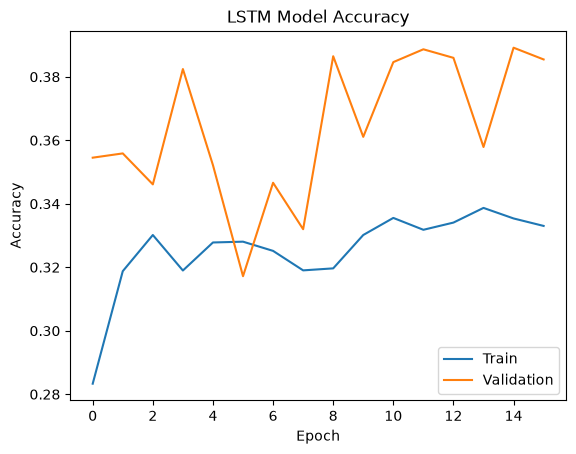

In [53]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("LSTM Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

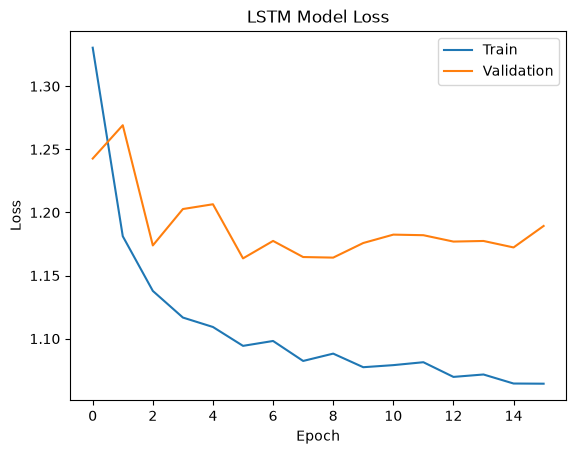

In [54]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("LSTM Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

In [55]:
model.save(
    r"D:\project\MindSense\Early_Detection\models\mental_health_lstm.keras"
)

In [56]:
import os

model_path = r"D:\project\MindSense\Early_Detection\models"

print(os.listdir(model_path))

['mental_health_lstm.keras']


In [57]:
y_train_labels = np.argmax(y_train, axis=1)

In [58]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np


class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_labels),
    y=y_train_labels
)


class_weights = dict(
    enumerate(class_weights)
)


print(class_weights)

{0: np.float64(0.46490079171146514), 1: np.float64(1.3103030303030303), 2: np.float64(10.407877461706784), 3: np.float64(1.2796341135324185), 4: np.float64(0.8276318078997738)}


In [59]:
print(np.unique(y_train_labels))

[0 1 2 3 5]


In [60]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.46490079171146514), 1: np.float64(1.3103030303030303), 2: np.float64(10.407877461706784), 3: np.float64(1.2796341135324185), 4: np.float64(0.8276318078997738)}


In [61]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


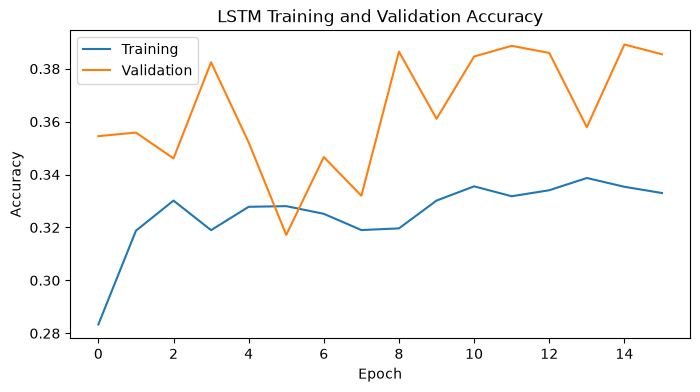

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("LSTM Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Training", "Validation"])

plt.show()

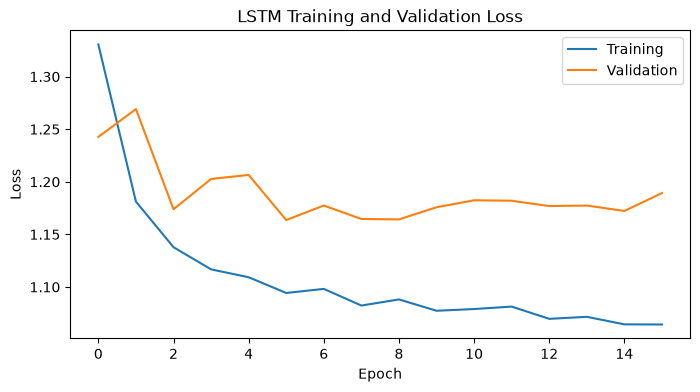

In [63]:
plt.figure(figsize=(8,4))

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Training", "Validation"])

plt.show()

In [64]:
model.save(
r"D:\project\MindSense\Early_Detection\models\mental_health_lstm_weighted.keras"
)

In [65]:
import pickle

with open(
    r"D:\MindSense\Early_Detection\results\training_history.pkl",
    "wb"
) as file:
    pickle.dump(history.history, file)

print("Training history saved")

Training history saved


In [66]:
import matplotlib.pyplot as plt

In [67]:
import os

print(os.path.exists(r"D:\MindSense\Early_Detection\results\plots"))

True


In [68]:
import os

os.makedirs(
    r"D:\MindSense\Early_Detection\results\plots",
    exist_ok=True
)

print("Folder created successfully")

Folder created successfully


In [69]:
plt.savefig(
    r"D:\MindSense\Early_Detection\results\plots\accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

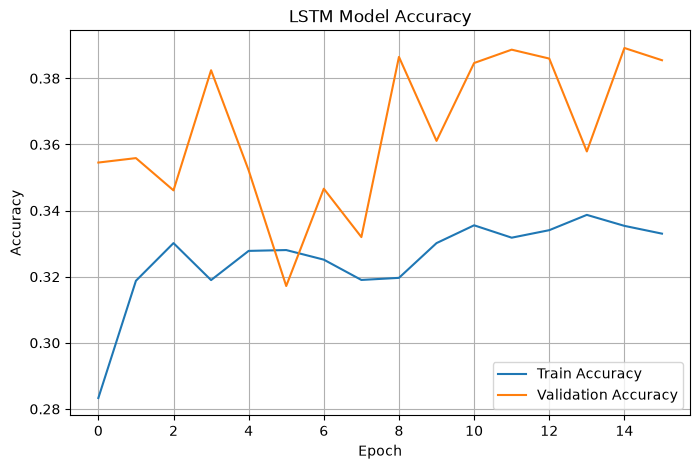

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("LSTM Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train Accuracy", "Validation Accuracy"])

plt.grid(True)

plt.savefig(
    r"D:\project\MindSense\Early_Detection\results\plots\accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

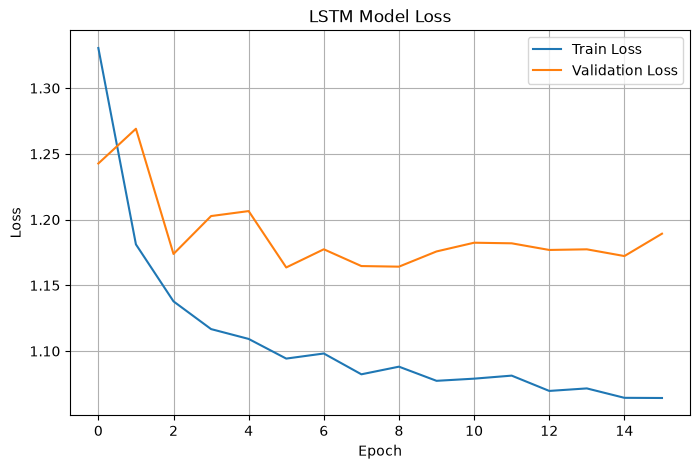

In [71]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("LSTM Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train Loss", "Validation Loss"])

plt.grid(True)

plt.savefig(
    r"D:\project\MindSense\Early_Detection\results\plots\loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [72]:
import pickle

with open(
    r"D:\project\MindSense\Early_Detection\results\training_history.pkl",
    "wb"
) as file:
    pickle.dump(history.history, file)

print("Training history saved")

Training history saved
